In [ ]:
import os
import pandas as pd

# Load your original training data
df = pd.read_csv('data/train.csv')
folder_path = "sampled_data"

# Stratified sampling: 2000 samples from each label (0-13)
sampled_df = (
    df.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=2000, random_state=42))
    .reset_index(drop=True)
)

# Create the folder (and any parent folders) if not exist
os.makedirs(folder_path, exist_ok=True)

# Save the balanced sampled data
sampled_df.to_csv(f'{folder_path}/sampled_train.csv', index=False)


C:\Users\himas\AppData\Local\Temp\ipykernel_23088\923122213.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=2000, random_state=42))


In [2]:
import os
import pandas as pd

# Load your original training data
df = pd.read_csv('data/test.csv')
folder_path = "sampled_data"

# Stratified sampling: 200 samples from each label (0-13)
sampled_df = (
    df.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(n=1000, random_state=42))
    .reset_index(drop=True)
)

# Create the folder (and any parent folders) if not exist
os.makedirs(folder_path, exist_ok=True)

# Save the balanced sampled data
sampled_df.to_csv(f'{folder_path}/sampled_test.csv', index=False)


C:\Users\himas\AppData\Local\Temp\ipykernel_23088\485120560.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=1000, random_state=42))


In [3]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

STOPWORDS = set(stopwords.words('english'))
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Remove all non-ASCII chars (non-English languages)
    text = re.sub(r'[^\x00-\x7F]+', ' ', str(text))
    # 2. Lowercase
    text = text.lower()
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Remove numeric digits
    text = re.sub(r'\d+', '', text)
    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 6. Remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS]
    # 7. Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Load the CSV
df = pd.read_csv('sampled_data/sampled_train.csv')

# Clean both title and content columns
df['title_clean'] = df['title'].astype(str).apply(clean_text)
df['content_clean'] = df['content'].astype(str).apply(clean_text)
df.drop(columns=['title', 'content'], inplace=True)

# Save cleaned data
df.to_csv('sampled_data/sampled_train_cleaned.csv', index=False)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\himas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\himas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

STOPWORDS = set(stopwords.words('english'))
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Remove all non-ASCII chars (non-English languages)
    text = re.sub(r'[^\x00-\x7F]+', ' ', str(text))
    # 2. Lowercase
    text = text.lower()
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 4. Remove numeric digits
    text = re.sub(r'\d+', '', text)
    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 6. Remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in STOPWORDS]
    # 7. Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Load the CSV
df = pd.read_csv('sampled_data/sampled_test.csv')

# Clean both title and content columns
df['title_clean'] = df['title'].astype(str).apply(clean_text)
df['content_clean'] = df['content'].astype(str).apply(clean_text)
df.drop(columns=['title', 'content'], inplace=True)

# Save cleaned data
df.to_csv('sampled_data/sampled_test_cleaned.csv', index=False)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\himas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\himas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Load cleaned data
df = pd.read_csv('sampled_data/sampled_train_cleaned.csv')

# You can use 'content_clean', 'title_clean', or combine them
df['text'] = df['title_clean'].astype(str) + ' ' + df['content_clean'].astype(str)

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # You can change max_features as needed

# Fit the vectorizer and transform the text
tfidf_matrix = vectorizer.fit_transform(df['text'])

# Convert TF-IDF result to Pandas DataFrame for inspection or downstream use
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Save TF-IDF features (optional, for debug or feature inspection)
tfidf_df.to_csv('sampled_data/sampled_train_tfidf.csv', index=False)

# Use `tfidf_matrix` for your GCN model input graph construction


In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import itertools
import collections
import pickle

# Load both train and test cleaned data
df_train = pd.read_csv('sampled_data/sampled_train_cleaned.csv')
df_test = pd.read_csv('sampled_data/sampled_test_cleaned.csv')  # Assuming you have similarly cleaned test set

# Combine dataframes for unified graph
df_full = pd.concat([df_train, df_test], ignore_index=True)
corpus = (df_full['title_clean'].astype(str) + ' ' + df_full['content_clean'].astype(str)).tolist()

# Assign node IDs
num_train = len(df_train)
num_test = len(df_test)
num_docs = len(df_full)
doc_ids = list(range(num_docs))

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(corpus)
vocab = vectorizer.get_feature_names_out()
word2id = {word: idx + num_docs for idx, word in enumerate(vocab)}  # word node ids start after docs

with open('sampled_data/doc_ids.pkl', 'wb') as f: pickle.dump(doc_ids, f)
with open('sampled_data/word2id.pkl', 'wb') as f: pickle.dump(word2id, f)

# Document–Word (TF-IDF) Edges
doc_word_edges = []
for doc_idx, row in enumerate(tfidf_matrix):
    for w_id in row.nonzero()[1]:
        word = vocab[w_id]
        word_idx = word2id[word]
        weight = row[0, w_id]
        doc_word_edges.append((doc_idx, word_idx, weight))

# Word–Word (PMI) Edges
window_size = 8
windows = []
for text in corpus:
    tokens = text.split()
    if len(tokens) <= window_size:
        windows.append(tokens)
    else:
        windows += [tokens[i:i+window_size] for i in range(len(tokens)-window_size+1)]

word_window_freq = collections.Counter()
pair_window_freq = collections.Counter()

for window in windows:
    win_set = set(window)
    for word in win_set:
        word_window_freq[word] += 1
    for pair in itertools.combinations(win_set, 2):
        pair_window_freq[pair] += 1

num_windows = len(windows)
word_word_edges = []
for (wi, wj), freq in pair_window_freq.items():
    if wi in word2id and wj in word2id:
        p_i = word_window_freq[wi] / num_windows
        p_j = word_window_freq[wj] / num_windows
        p_ij = freq / num_windows
        pmi = np.log(p_ij / (p_i * p_j))
        if pmi > 0:
            word_word_edges.append((word2id[wi], word2id[wj], pmi))

# Combine and save edges
edges = doc_word_edges + word_word_edges
edge_index = np.array([(src, tgt) for src, tgt, weight in edges]).T
edge_weight = np.array([weight for src, tgt, weight in edges])
np.save('sampled_data/edge_index_full.npy', edge_index)
np.save('sampled_data/edge_weight_full.npy', edge_weight)

edge_df = pd.DataFrame(edges, columns=['source_node', 'target_node', 'weight'])
edge_df.to_csv('sampled_data/graph_edges_full.csv', index=False)

# Create and save node feature matrix
doc_features = tfidf_matrix.toarray()
word_features = np.eye(len(vocab))
if doc_features.shape[1] < word_features.shape[1]:
    pad_width = word_features.shape[1] - doc_features.shape[1]
    doc_features = np.pad(doc_features, ((0,0),(0,pad_width)), 'constant')
elif doc_features.shape[1] > word_features.shape[1]:
    pad_width = doc_features.shape[1] - word_features.shape[1]
    word_features = np.pad(word_features, ((0,0),(0,pad_width)), 'constant')

node_features = np.vstack([doc_features, word_features])
np.save('sampled_data/node_features_full.npy', node_features)

# Create labels: train document nodes have their labels, test document nodes are masked (-1)
labels = np.concatenate([
    df_train['label'].values, 
    np.full(num_test, -1)  # Assign -1 to test documents
])
np.save('sampled_data/labels_full.npy', labels)

print(f"Transductive graph built!\nDocs: {num_docs} (train: {num_train}, test: {num_test}), Words: {len(vocab)}, Total nodes: {node_features.shape[0]}, Edges: {len(edges)}")


Transductive graph built!
Docs: 42000 (train: 28000, test: 14000), Words: 5000, Total nodes: 47000, Edges: 1673486


In [7]:
import numpy as np
import pandas as pd
import os

DATA_DIR = 'sampled_data'
train_csv = os.path.join(DATA_DIR, 'sampled_train_cleaned.csv')
test_csv  = os.path.join(DATA_DIR, 'sampled_test_cleaned.csv')
out_path  = os.path.join(DATA_DIR, 'true_labels_full.npy')

df_train = pd.read_csv(train_csv)
df_test  = pd.read_csv(test_csv)

true_labels_full = np.concatenate([df_train['label'].values, df_test['label'].values])
np.save(out_path, true_labels_full)
print("Saved:", out_path, "shape:", true_labels_full.shape)


Saved: sampled_data\true_labels_full.npy shape: (42000,)


In [8]:
import numpy as np

# Load saved graph edges (source-target node indices)
edge_index = np.load('sampled_data/edge_index_full.npy')
edge_weight = np.load('sampled_data/edge_weight_full.npy')

num_docs = 42000  # Set this to your real doc count

print("Edge index shape:", edge_index.shape)
print("Edge weight shape:", edge_weight.shape)

n = min(50, edge_index.shape[1])
for i in range(n):
    src = edge_index[0, i]
    tgt = edge_index[1, i]
    weight = edge_weight[i]
    if (src < num_docs and tgt >= num_docs) or (tgt < num_docs and src >= num_docs):
        etype = 'DOC-WORD'
    elif src >= num_docs and tgt >= num_docs:
        etype = 'WORD-WORD'
    else:
        etype = 'OTHER'
    print(f"Edge {i:2d}: {src:5d} -> {tgt:5d}, weight = {weight:8.4f}   [{etype}]")


Edge index shape: (2, 1673486)
Edge weight shape: (1673486,)
Edge  0:     0 -> 46339, weight =   0.2908   [DOC-WORD]
Edge  1:     0 -> 42962, weight =   0.2132   [DOC-WORD]
Edge  2:     0 -> 43831, weight =   0.5041   [DOC-WORD]
Edge  3:     0 -> 43263, weight =   0.1720   [DOC-WORD]
Edge  4:     0 -> 42937, weight =   0.2462   [DOC-WORD]
Edge  5:     0 -> 42392, weight =   0.1305   [DOC-WORD]
Edge  6:     0 -> 45029, weight =   0.2137   [DOC-WORD]
Edge  7:     0 -> 43769, weight =   0.1356   [DOC-WORD]
Edge  8:     0 -> 43260, weight =   0.1917   [DOC-WORD]
Edge  9:     0 -> 46059, weight =   0.1596   [DOC-WORD]
Edge 10:     0 -> 45301, weight =   0.2123   [DOC-WORD]
Edge 11:     0 -> 43125, weight =   0.1429   [DOC-WORD]
Edge 12:     0 -> 46945, weight =   0.1964   [DOC-WORD]
Edge 13:     0 -> 44682, weight =   0.1637   [DOC-WORD]
Edge 14:     0 -> 42166, weight =   0.1867   [DOC-WORD]
Edge 15:     0 -> 44721, weight =   0.1390   [DOC-WORD]
Edge 16:     0 -> 45173, weight =   0.1774 

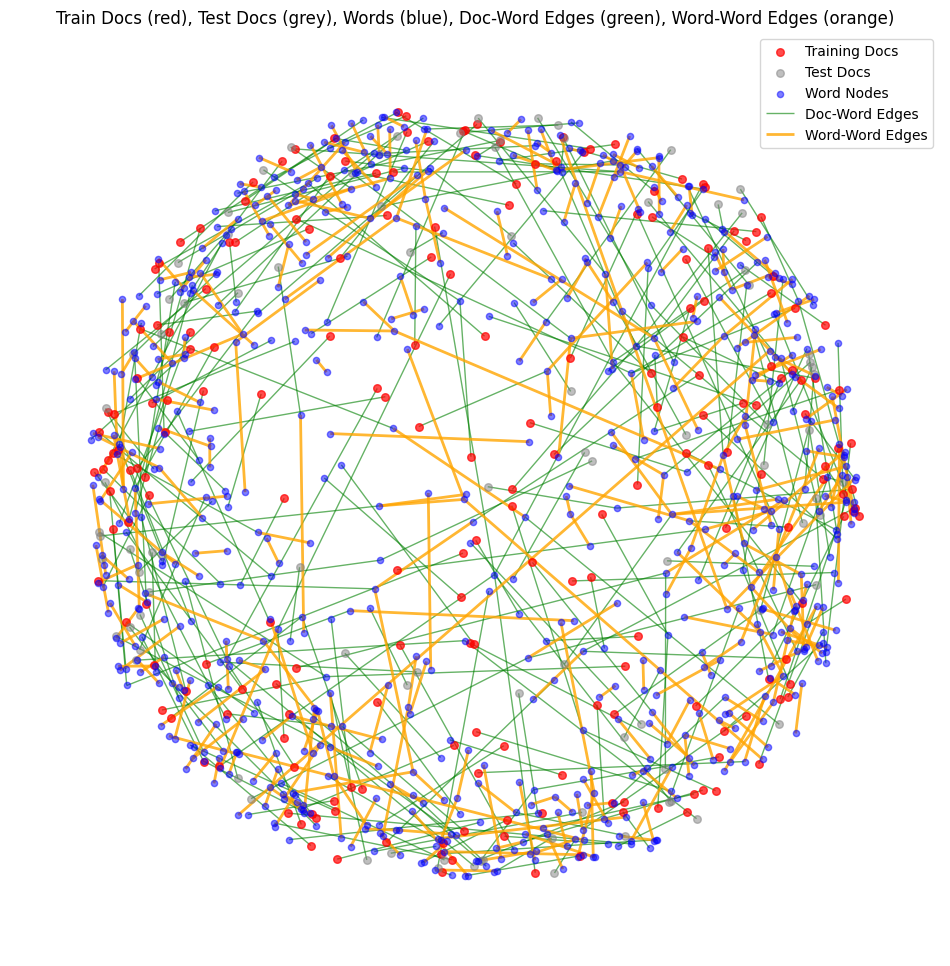

In [9]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random

# Load edge and weight arrays
edge_index = np.load('sampled_data/edge_index_full.npy')
edge_weight = np.load('sampled_data/edge_weight_full.npy')

num_train = 28000  # update to your actual train doc count
num_test = 14000   # update to your actual test doc count
num_docs = num_train + num_test
num_words = 5000

# Separate edges by type
doc_word_edges = []
word_word_edges = []

for i in range(edge_index.shape[1]):
    src = edge_index[0, i]
    tgt = edge_index[1, i]
    weight = edge_weight[i]

    if (src < num_docs and tgt >= num_docs) or (tgt < num_docs and src >= num_docs):
        doc_word_edges.append((src, tgt, weight))
    elif src >= num_docs and tgt >= num_docs:
        word_word_edges.append((src, tgt, weight))

sample_size = 300
sampled_doc_word = random.sample(doc_word_edges, min(sample_size, len(doc_word_edges)))
sampled_word_word = random.sample(word_word_edges, min(sample_size, len(word_word_edges)))

sampled_edges = sampled_doc_word + sampled_word_word

# Build graph
G = nx.Graph()
for src, tgt, weight in sampled_edges:
    G.add_edge(src, tgt, weight=weight)

pos = nx.spring_layout(G, k=0.15)

# Node sets
train_nodes = [n for n in G.nodes if n < num_train]
test_nodes = [n for n in G.nodes if n >= num_train and n < num_docs]
word_nodes = [n for n in G.nodes if n >= num_docs]

# Separate edges for coloring
doc_word_edges_in_graph = [e for e in G.edges if (e[0] < num_docs and e[1] >= num_docs) or (e[1] < num_docs and e[0] >= num_docs)]
word_word_edges_in_graph = [e for e in G.edges if e[0] >= num_docs and e[1] >= num_docs]

plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, nodelist=train_nodes, node_color='red', node_size=30, alpha=0.7, label='Training Docs')
nx.draw_networkx_nodes(G, pos, nodelist=test_nodes, node_color='grey', node_size=30, alpha=0.5, label='Test Docs')
nx.draw_networkx_nodes(G, pos, nodelist=word_nodes, node_color='blue', node_size=20, alpha=0.5, label='Word Nodes')
nx.draw_networkx_edges(G, pos, edgelist=doc_word_edges_in_graph, edge_color='green', width=1.0, alpha=0.6, label='Doc-Word Edges')
nx.draw_networkx_edges(G, pos, edgelist=word_word_edges_in_graph, edge_color='orange', width=2.0, alpha=0.8, label='Word-Word Edges')

plt.title('Train Docs (red), Test Docs (grey), Words (blue), Doc-Word Edges (green), Word-Word Edges (orange)')
plt.legend()
plt.axis('off')
plt.show()


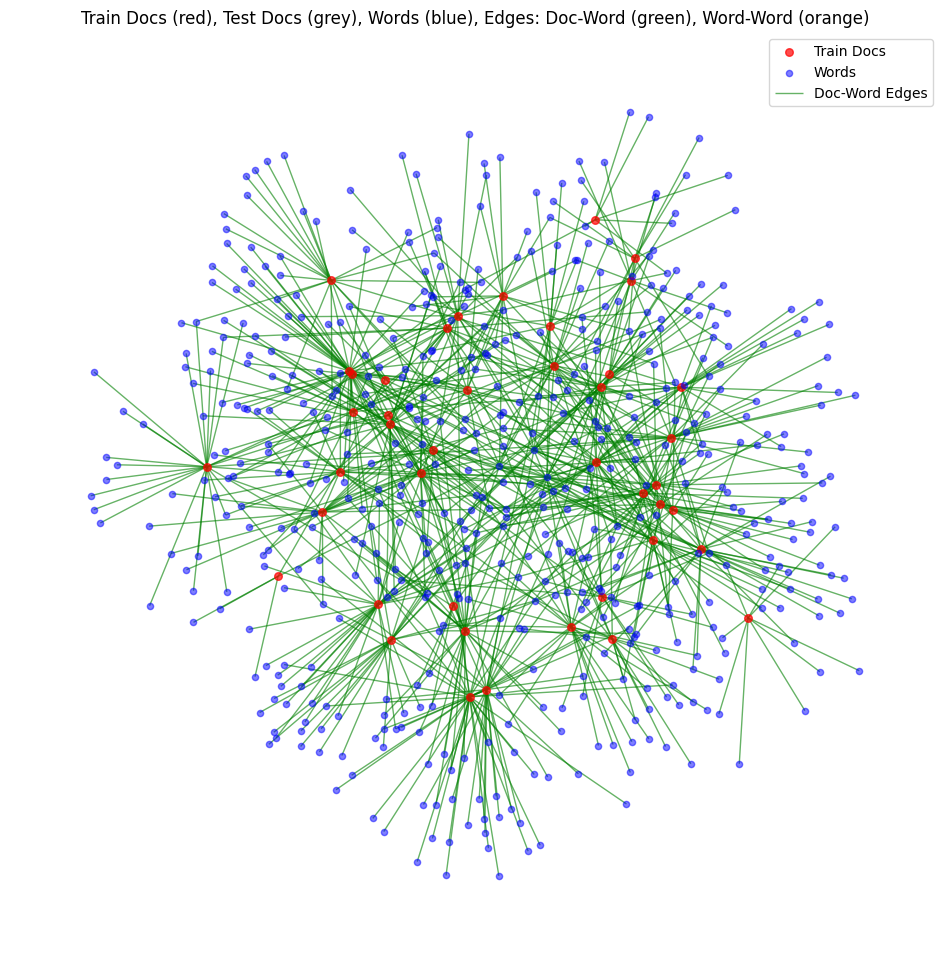

In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

edge_index = np.load('sampled_data/edge_index_full.npy')
edge_weight = np.load('sampled_data/edge_weight_full.npy')

num_train = 28000  # Docs in training set
num_test = 14000   # Docs in test set
num_docs = num_train + num_test
num_words = 5000

G = nx.Graph()
for i in range(min(800, edge_index.shape[1])):
    src = edge_index[0, i]
    tgt = edge_index[1, i]
    weight = edge_weight[i]
    G.add_edge(src, tgt, weight=weight)

pos = nx.spring_layout(G, k=0.1)

train_nodes = [n for n in G.nodes if n < num_train]
test_nodes = [n for n in G.nodes if n >= num_train and n < num_docs]
word_nodes = [n for n in G.nodes if n >= num_docs]

plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, nodelist=train_nodes, node_color='red', node_size=30, alpha=0.7, label='Train Docs')
nx.draw_networkx_nodes(G, pos, nodelist=test_nodes, node_color='grey', node_size=30, alpha=0.6, label='Test Docs')
nx.draw_networkx_nodes(G, pos, nodelist=word_nodes, node_color='blue', node_size=20, alpha=0.5, label='Words')

doc_word_edges = [e for e in G.edges if (e[0] < num_docs and e[1] >= num_docs) or (e[1] < num_docs and e[0] >= num_docs)]
word_word_edges = [e for e in G.edges if e[0] >= num_docs and e[1] >= num_docs]
nx.draw_networkx_edges(G, pos, edgelist=doc_word_edges, edge_color='green', width=1.0, alpha=0.6, label='Doc-Word Edges')
nx.draw_networkx_edges(G, pos, edgelist=word_word_edges, edge_color='orange', width=2.0, alpha=0.8, label='Word-Word Edges')

plt.title('Train Docs (red), Test Docs (grey), Words (blue), Edges: Doc-Word (green), Word-Word (orange)')
plt.legend()
plt.axis('off')
plt.show()


In [11]:
# TRAINING SCRIPT (fixed post-train evaluation)
# Paste into notebook where sampled_data/ exists.
import os, time, json
import numpy as np
import scipy.sparse as sp
import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# CONFIG
DATA_DIR = 'sampled_data'
EDGE_INDEX_PATH = os.path.join(DATA_DIR, 'edge_index_full.npy')
EDGE_WEIGHT_PATH = os.path.join(DATA_DIR, 'edge_weight_full.npy')
NODE_FEATURES_PATH = os.path.join(DATA_DIR, 'node_features_full.npy')
LABELS_PATH = os.path.join(DATA_DIR, 'labels_full.npy')
SAMPLED_TEST_CSV = os.path.join(DATA_DIR, 'sampled_test_cleaned.csv')  # optional for final eval
OUT_MODEL_PATH = os.path.join(DATA_DIR, 'gcn_model.pth')
OUT_HISTORY = os.path.join(DATA_DIR, 'train_history.json')
OUT_PRED = os.path.join(DATA_DIR, 'predictions.npy')
OUT_SUMMARY = os.path.join(DATA_DIR, 'train_summary.json')

# Hyperparams
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HIDDEN = 200
LR = 0.02
WEIGHT_DECAY = 5e-4
DROPOUT = 0.5
EPOCHS = 200
PATIENCE = 30
VAL_RATIO = 0.10
PRINT_EVERY = 10

np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(SEED)

# UTILITIES
def make_adj_from_edges(edge_index, edge_weight, num_nodes):
    src = np.array(edge_index[0], dtype=np.int64)
    dst = np.array(edge_index[1], dtype=np.int64)
    data = np.array(edge_weight, dtype=np.float32)
    coo = sp.coo_matrix((data, (src, dst)), shape=(num_nodes, num_nodes), dtype=np.float32).tocoo()
    coo = coo + coo.transpose()
    csr = coo.tocsr()
    diag = csr.diagonal()
    if np.any(diag == 0):
        csr = csr + sp.eye(num_nodes, dtype=np.float32, format='csr')
    return csr

def normalize_adj_sym(adj_csr):
    adj = adj_csr.tocoo()
    rowsum = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(rowsum, -0.5, where=rowsum>0)
    d_inv_sqrt[~np.isfinite(d_inv_sqrt)] = 0.0
    D_inv_sqrt = sp.diags(d_inv_sqrt)
    return (D_inv_sqrt.dot(adj).dot(D_inv_sqrt)).tocoo()

def coo_to_torch_sparse(adj_coo, device=DEVICE):
    coo = adj_coo.tocoo()
    indices = np.vstack((coo.row, coo.col)).astype(np.int64)
    i = torch.LongTensor(indices).to(device)
    v = torch.FloatTensor(coo.data).to(device)
    return torch.sparse_coo_tensor(i, v, (coo.shape[0], coo.shape[1])).coalesce()

class GCN(nn.Module):
    def __init__(self, in_feats, hidden, n_classes, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_feats, hidden, bias=False)
        self.lin2 = nn.Linear(hidden, n_classes, bias=False)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, adj_sparse):
        x = torch.spmm(adj_sparse, x)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = torch.spmm(adj_sparse, x)
        x = self.lin2(x)
        return x

# LOAD
for p in [EDGE_INDEX_PATH, EDGE_WEIGHT_PATH, NODE_FEATURES_PATH, LABELS_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing required file: {p}")

edge_index = np.load(EDGE_INDEX_PATH)
edge_weight = np.load(EDGE_WEIGHT_PATH)
X = np.load(NODE_FEATURES_PATH).astype(np.float32)
doc_labels = np.load(LABELS_PATH)   # shape = (num_docs,) with -1 for test docs

num_docs = int(doc_labels.shape[0])
num_nodes = int(X.shape[0])
num_words = num_nodes - num_docs
print("num_docs=", num_docs, "num_words=", num_words, "total_nodes=", num_nodes, "feat_dim=", X.shape[1])

# Build adjacency & normalized torch sparse
adj_csr = make_adj_from_edges(edge_index, edge_weight, num_nodes)
adj_norm = normalize_adj_sym(adj_csr)
adj_torch = coo_to_torch_sparse(adj_norm, device=DEVICE)
print("Adjacency ready. nnz:", adj_csr.nnz)

# Features & node labels
X_torch = torch.tensor(X, dtype=torch.float32, device=DEVICE)
node_labels = np.full(num_nodes, -1, dtype=np.int64)
node_labels[:num_docs] = doc_labels.astype(np.int64)
y_torch = torch.tensor(node_labels, dtype=torch.long, device=DEVICE)

# train/val split from labeled docs
labeled_docs = np.where(node_labels[:num_docs] != -1)[0]
if labeled_docs.size == 0:
    raise RuntimeError("No labeled docs found in labels file.")
train_docs, val_docs = train_test_split(labeled_docs, test_size=VAL_RATIO, random_state=SEED, stratify=node_labels[labeled_docs])
train_idx = torch.tensor(train_docs, dtype=torch.long, device=DEVICE)
val_idx = torch.tensor(val_docs, dtype=torch.long, device=DEVICE)
test_docs = np.where(node_labels[:num_docs] == -1)[0]
test_idx = torch.tensor(test_docs, dtype=torch.long, device=DEVICE)
print("Train/Val/Test counts:", len(train_docs), len(val_docs), len(test_docs))

# Model init
num_classes = int(np.max(node_labels[:num_docs]) + 1)
model = GCN(in_feats=X_torch.shape[1], hidden=HIDDEN, n_classes=num_classes, dropout=DROPOUT).to(DEVICE)
opt = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'epoch_time':[]}
best_val = float('inf'); best_state = None; wait = 0

print("Starting training on", DEVICE)
t0_all = time.time()
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    model.train()
    logits = model(X_torch, adj_torch)
    loss = criterion(logits[train_idx], y_torch[train_idx])
    opt.zero_grad(); loss.backward(); opt.step()
    epoch_time = time.time() - t0

    model.eval()
    with torch.no_grad():
        logits_all = model(X_torch, adj_torch)
        train_loss = criterion(logits_all[train_idx], y_torch[train_idx]).item()
        train_preds = logits_all[train_idx].argmax(dim=1).cpu().numpy()
        train_true = y_torch[train_idx].cpu().numpy()
        train_acc = accuracy_score(train_true, train_preds)

        val_loss = criterion(logits_all[val_idx], y_torch[val_idx]).item()
        val_preds = logits_all[val_idx].argmax(dim=1).cpu().numpy()
        val_true = y_torch[val_idx].cpu().numpy()
        val_acc = accuracy_score(val_true, val_preds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(float(train_acc))
    history['val_acc'].append(float(val_acc))
    history['epoch_time'].append(epoch_time)

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k:v.cpu() for k,v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % PRINT_EVERY == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS} train_loss={train_loss:.4f} val_loss={val_loss:.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f} time={epoch_time:.3f}s")
    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

total_time = time.time() - t0_all
print("Training done in {:.1f}s".format(total_time))

# load best model (if any) and re-evaluate val set with it
if best_state is not None:
    model.load_state_dict({k:v.to(DEVICE) for k,v in best_state.items()})
    print("Loaded best model (by val loss).")

# Save model & history
torch.save(model.state_dict(), OUT_MODEL_PATH)
with open(OUT_HISTORY, 'w') as fh:
    json.dump(history, fh)
print("Saved model ->", OUT_MODEL_PATH)
print("Saved history ->", OUT_HISTORY)

# Inference (final)
model.eval()
with torch.no_grad():
    logits_all = model(X_torch, adj_torch)
    probs_all = F.softmax(logits_all, dim=1).cpu().numpy()
    hidden = logits_all.cpu().numpy()

preds_all = logits_all.argmax(dim=1).cpu().numpy()
doc_preds = preds_all[:num_docs]
np.save(OUT_PRED, doc_preds)
print("Saved doc predictions ->", OUT_PRED)

# Final eval on train & val using final model
with torch.no_grad():
    logits_all = model(X_torch, adj_torch)
final_train_preds = logits_all[train_idx].argmax(dim=1).cpu().numpy()
final_val_preds = logits_all[val_idx].argmax(dim=1).cpu().numpy()
final_train_true = y_torch[train_idx].cpu().numpy()
final_val_true = y_torch[val_idx].cpu().numpy()

print("Final train acc:", accuracy_score(final_train_true, final_train_preds))
print("Final val acc:", accuracy_score(final_val_true, final_val_preds))
print("Val classification report:\n", classification_report(final_val_true, final_val_preds, digits=4))

# Try evaluate on sampled_test_cleaned.csv if order matches (train then test)
if os.path.exists(SAMPLED_TEST_CSV):
    df_test = pd.read_csv(SAMPLED_TEST_CSV)
    true_test = df_test['label'].values
    num_train = int(np.sum(node_labels[:num_docs] != -1))
    if num_train + len(true_test) == num_docs:
        test_preds_final = doc_preds[num_train:num_train + len(true_test)]
        print("Test acc:", accuracy_score(true_test, test_preds_final))
        print("Test report:\n", classification_report(true_test, test_preds_final, digits=4))
    else:
        print("WARNING: Could not align sampled_test_cleaned.csv with graph doc indices. Provide num_train if different.")

# Save summary JSON
summary = {
    'num_nodes': int(num_nodes), 'num_docs': int(num_docs), 'num_words': int(num_words),
    'train_count': int(len(train_docs)), 'val_count': int(len(val_docs)), 'test_count': int(len(test_docs)),
    'model_path': OUT_MODEL_PATH, 'predictions_path': OUT_PRED
}
with open(OUT_SUMMARY, 'w') as fh:
    json.dump(summary, fh, indent=2)
print("Saved summary ->", OUT_SUMMARY)


num_docs= 42000 num_words= 5000 total_nodes= 47000 feat_dim= 5000
Adjacency ready. nnz: 3322392
Train/Val/Test counts: 25200 2800 14000
Starting training on cuda
Epoch 1/200 train_loss=2.6335 val_loss=2.6334 train_acc=0.6037 val_acc=0.6171 time=3.305s
Epoch 10/200 train_loss=2.2885 val_loss=2.2860 train_acc=0.4765 val_acc=0.4850 time=2.544s
Epoch 20/200 train_loss=1.8786 val_loss=1.8789 train_acc=0.5811 val_acc=0.5800 time=2.561s
Epoch 30/200 train_loss=1.5517 val_loss=1.5553 train_acc=0.6892 val_acc=0.6804 time=2.593s
Epoch 40/200 train_loss=1.3296 val_loss=1.3344 train_acc=0.7601 val_acc=0.7525 time=2.620s
Epoch 50/200 train_loss=1.1891 val_loss=1.1949 train_acc=0.8236 val_acc=0.8264 time=2.610s
Epoch 60/200 train_loss=1.0980 val_loss=1.1044 train_acc=0.8696 val_acc=0.8682 time=2.631s
Epoch 70/200 train_loss=1.0391 val_loss=1.0464 train_acc=0.8871 val_acc=0.8829 time=2.592s
Epoch 80/200 train_loss=1.0050 val_loss=1.0130 train_acc=0.8942 val_acc=0.8939 time=2.597s
Epoch 90/200 train_l

In [1]:
# Visualization + Interactive HTML (pyvis)
# Paste into a notebook cell and run (same folder as sampled_data/)
import os, json
import numpy as np
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DATA_DIR = "sampled_data"
OUT_DIR = os.path.join(DATA_DIR, "presentation_assets"); os.makedirs(OUT_DIR, exist_ok=True)

EDGE_INDEX_PATH = os.path.join(DATA_DIR, "edge_index_full.npy")
EDGE_WEIGHT_PATH = os.path.join(DATA_DIR, "edge_weight_full.npy")
NODE_FEATS_PATH = os.path.join(DATA_DIR, "node_features_full.npy")
LABELS_MASKED_PATH = os.path.join(DATA_DIR, "labels_full.npy")        # train + -1 for test
TRUE_LABELS_PATH = os.path.join(DATA_DIR, "true_labels_full.npy")     # optional (train+test true labels)
PRED_PATH = os.path.join(DATA_DIR, "predictions.npy")                 # doc predictions

# Choose center doc:
# Option A: set absolute graph node id (graph doc id in [0..num_docs-1])
example_doc_node = 41501
# Option B: set offset into test-block (0 => first test doc)
example_doc_offset = 10

# visualization parameters
MAX_NEIGHBORS = 80
SPRING_K = 0.25
SEED = 42
EDGE_WEIGHT_THRESHOLD = 0.0   # prune edges weaker than this (0 => no prune)

# ---------------- optional pyvis ----------------
try:
    from pyvis.network import Network
    PYVIS_AVAILABLE = True
except Exception:
    PYVIS_AVAILABLE = False

# ---------------- validate files ----------------
for p in (EDGE_INDEX_PATH, EDGE_WEIGHT_PATH, NODE_FEATS_PATH, LABELS_MASKED_PATH, PRED_PATH):
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing required file: {p}")

# ---------------- load arrays ----------------
edge_index = np.load(EDGE_INDEX_PATH)
edge_weight = np.load(EDGE_WEIGHT_PATH)
node_feats = np.load(NODE_FEATS_PATH)
labels_masked = np.load(LABELS_MASKED_PATH)   # shape = (num_docs,) with -1 for test
preds = np.load(PRED_PATH)

num_docs = labels_masked.shape[0]
num_nodes = node_feats.shape[0]
num_words = num_nodes - num_docs
num_train = int(np.sum(labels_masked[:num_docs] != -1))

true_labels = None
if os.path.exists(TRUE_LABELS_PATH):
    arr = np.load(TRUE_LABELS_PATH)
    if arr.shape[0] == num_docs:
        true_labels = arr
    else:
        print("Warning: true_labels_full.npy length mismatch -> ignoring it (fall back to masked labels).")

# pick example doc graph id
if example_doc_node is None:
    example_doc_idx = num_train + example_doc_offset
else:
    example_doc_idx = int(example_doc_node)
if example_doc_idx < 0 or example_doc_idx >= num_docs:
    raise ValueError("example_doc_idx out of range")

print(f"num_train={num_train}  example_doc_idx={example_doc_idx}")

# ---------------- adjacency (symmetrize) ----------------
src = edge_index[0].astype(np.int64)
dst = edge_index[1].astype(np.int64)
w = edge_weight.astype(np.float32)
coo = sp.coo_matrix((w, (src, dst)), shape=(num_nodes, num_nodes), dtype=np.float32)
coo = coo + coo.transpose()
adj_csr = coo.tocsr()
# ensure self-loops (not strictly necessary for plotting)
if np.any(adj_csr.diagonal() == 0):
    adj_csr = adj_csr + sp.eye(num_nodes, dtype=np.float32, format='csr')

# ---------------- build k=1 subgraph around center ----------------
def get_k1_subgraph(adj_csr, center, max_neighbors=MAX_NEIGHBORS, threshold=EDGE_WEIGHT_THRESHOLD):
    row = adj_csr.getrow(center).tocoo()
    neigh = row.col.tolist()
    weights = row.data.tolist()
    pairs = [(int(n), float(w)) for n,w in zip(neigh, weights) if int(n) != center and float(w) > threshold]
    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)[:max_neighbors]
    nodes = sorted({center} | {p[0] for p in pairs})
    sub = adj_csr[nodes, :][:, nodes].tocoo()
    rows, cols, dat = sub.row, sub.col, sub.data
    edges = []
    for i in range(len(dat)):
        u = nodes[int(rows[i])]
        v = nodes[int(cols[i])]
        weight = float(dat[i])
        if u == v: continue
        a,b = (u,v) if u<=v else (v,u)
        edges.append((a,b,weight))
    # deduplicate and keep max weight if multiple
    uniq = {}
    for u,v,wt in edges:
        if (u,v) not in uniq or uniq[(u,v)] < wt:
            uniq[(u,v)] = wt
    edges_uniq = [(u,v,uniq[(u,v)]) for (u,v) in sorted(uniq.keys())]
    return nodes, edges_uniq, {n:i for i,n in enumerate(nodes)}

sub_nodes, sub_edges, _ = get_k1_subgraph(adj_csr, example_doc_idx)
print("Subgraph nodes:", len(sub_nodes), "edges:", len(sub_edges))

# ---------------- create networkx graph ----------------
G = nx.Graph()
G.add_nodes_from(sub_nodes)
for u,v,wt in sub_edges:
    if u!=v:
        G.add_edge(u,v, weight=float(wt))

# ---------------- node visuals ----------------
node_colors = []
node_sizes = []
word_labels = {}
for n in G.nodes():
    if n == example_doc_idx:
        node_colors.append("grey")   # center test doc
        node_sizes.append(260)
    elif n < num_docs:
        # document node: colored red if training, light grey if test (not center)
        if labels_masked[n] != -1:
            node_colors.append("#ff6666")  # train doc
            node_sizes.append(140)
        else:
            node_colors.append("#bdbdbd")  # other test docs
            node_sizes.append(120)
    else:
        node_colors.append("#4da6ff")      # word node
        node_sizes.append(70)
        word_labels[n] = f"W{n-num_docs}"

# ---------------- edge visuals: grey only if connected to center, else blue; thickness ~ weight -----------
edge_list = list(G.edges())
edge_weights = [float(G[u][v].get("weight",1.0)) for u,v in edge_list]
if len(edge_weights):
    # scale widths: use sqrt to compress range, then map to [0.6,4.2]
    ws = np.sqrt(np.array(edge_weights))
    wmin, wmax = float(ws.min()), float(ws.max())
    span = wmax - wmin if wmax - wmin > 1e-12 else 1.0
    widths = (0.6 + 3.6 * (ws - wmin) / span).tolist()
else:
    widths = [1.0]*len(edge_list)

edge_colors = []
for (u,v) in edge_list:
    if example_doc_idx in (u,v):
        edge_colors.append("grey")       # only edges touching center doc are grey
    else:
        edge_colors.append("#1f77b4")    # other edges blue

# ---------------- static PNG plot ----------------
plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, seed=SEED, k=SPRING_K)

nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color=edge_colors, width=widths, alpha=0.9)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
# draw only word labels (keeps view clean)
if word_labels:
    nx.draw_networkx_labels(G, pos, labels=word_labels, font_size=8)

# text info box with true & pred
center_true = (int(true_labels[example_doc_idx]) if true_labels is not None else (int(labels_masked[example_doc_idx]) if labels_masked[example_doc_idx] != -1 else None))
center_pred = int(preds[example_doc_idx]) if example_doc_idx < len(preds) else None
info_lines = [
    f"Document: D{example_doc_idx}",
    f"True label  : {center_true if center_true is not None else '(unavailable)'}",
    f"Pred label  : {center_pred if center_pred is not None else 'N/A'}"
]
plt.gcf().text(0.74, 0.58, "\n".join(info_lines), fontsize=11, bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="black", alpha=0.95))

plt.title(f"k=1 subgraph around doc {example_doc_idx} (edges touching center = grey)")
plt.axis("off")
png_out = os.path.join(OUT_DIR, f"subgraph_{example_doc_idx}.png")
plt.tight_layout(); plt.savefig(png_out, dpi=200); plt.close()
print("Saved static PNG ->", png_out)

# ---------------- optional interactive pyvis ----------------
out_html = None
if PYVIS_AVAILABLE:
    try:
        nt = Network(height="720px", width="100%", notebook=False, cdn_resources='in_line')
        nt.force_atlas_2based()
        nodes = list(G.nodes())
        # add nodes with tooltip text (True/Pred)
        for idx, n in enumerate(nodes):
            if n < num_docs:
                t = (int(true_labels[n]) if true_labels is not None else (int(labels_masked[n]) if labels_masked[n] != -1 else None))
                p = int(preds[n]) if n < len(preds) else None
                title = f"Node D{n}<br>True: {t if t is not None else '(unavail)'}<br>Pred: {p if p is not None else 'N/A'}"
                label = f"D{n}" if n < num_docs else f"W{n-num_docs}"
            else:
                title = f"Word W{n-num_docs}"
                label = f"W{n-num_docs}"
            color = node_colors[idx]
            size = max(8, min(60, int(node_sizes[idx] / 4)))
            nt.add_node(str(n), label=label, title=title, color=color, size=size)

        # add edges (color grey if touches center else blue)
        for (u,v), col, width in zip(edge_list, edge_colors, widths):
            nt.add_edge(str(u), str(v), color=col, width=max(1.0, float(width)))

        tmp_html = os.path.join(DATA_DIR, f"subgraph_{example_doc_idx}.tmp.html")
        out_html = os.path.join(DATA_DIR, f"subgraph_{example_doc_idx}.html")
        nt.write_html(tmp_html)

        # inject legend/center info HTML
        legend_html = f"""
        <div style="position:fixed; right:10px; top:10px; background:white; border:1px solid #ddd; padding:10px; z-index:9999;">
          <b>Legend</b><br/>
          <div style="margin-top:6px;"><span style='display:inline-block;width:12px;height:12px;background:#ff6666;margin-right:6px;'></span>Train doc</div>
          <div style="margin-top:6px;"><span style='display:inline-block;width:12px;height:12px;background:#bdbdbd;margin-right:6px;'></span>Other test doc</div>
          <div style="margin-top:6px;"><span style='display:inline-block;width:12px;height:12px;background:#4da6ff;margin-right:6px;'></span>Word node</div>
          <hr style="margin:8px 0"/>
          <div><b>Center D{example_doc_idx}</b></div>
          <div>True: {center_true if center_true is not None else '(unavailable)'}</div>
          <div>Pred: {center_pred if center_pred is not None else 'N/A'}</div>
        </div>
        """
        with open(tmp_html, "r", encoding="utf-8") as fh:
            html_text = fh.read()
        html_text = html_text.replace("</body>", legend_html + "\n</body>")
        with open(out_html, "w", encoding="utf-8") as fh:
            fh.write(html_text)
        os.remove(tmp_html)
        print("Saved interactive HTML ->", out_html)
    except Exception as e:
        print("pyvis export failed:", e)
else:
    print("pyvis not installed. Install with: pip install pyvis to get interactive HTML")

# ---------------- summary ----------------
summary = {"png": png_out, "html": out_html}
with open(os.path.join(OUT_DIR, "assets_summary.json"), "w") as fh:
    json.dump(summary, fh, indent=2)

print("Done. Summary:", summary)
print("Open the HTML in a browser (double-click) to interactively inspect nodes and hover tooltips.")


num_train=28000  example_doc_idx=41501
Subgraph nodes: 32 edges: 253
Saved static PNG -> sampled_data\presentation_assets\subgraph_41501.png
Saved interactive HTML -> sampled_data\subgraph_41501.html
Done. Summary: {'png': 'sampled_data\\presentation_assets\\subgraph_41501.png', 'html': 'sampled_data\\subgraph_41501.html'}
Open the HTML in a browser (double-click) to interactively inspect nodes and hover tooltips.


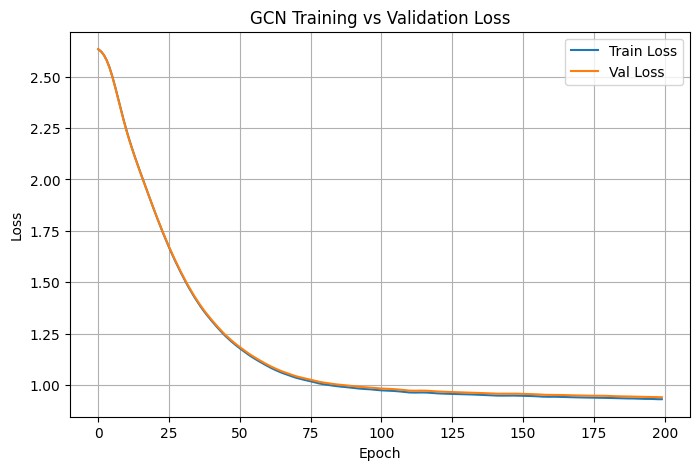

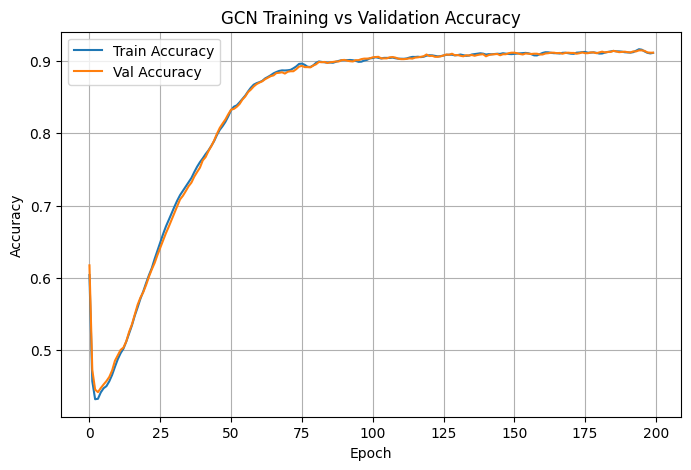

In [1]:
import json
import matplotlib.pyplot as plt

# Load saved history
with open("sampled_data/train_history.json", "r") as f:
    hist = json.load(f)

train_loss = hist["train_loss"]
val_loss = hist["val_loss"]
train_acc = hist["train_acc"]
val_acc = hist["val_acc"]

# ---- Plot Loss ----
plt.figure(figsize=(8,5))
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GCN Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_curve.png", dpi=200)
plt.show()

# ---- Plot Accuracy ----
plt.figure(figsize=(8,5))
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GCN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("accuracy_curve.png", dpi=200)
plt.show()


<Figure size 1000x800 with 0 Axes>

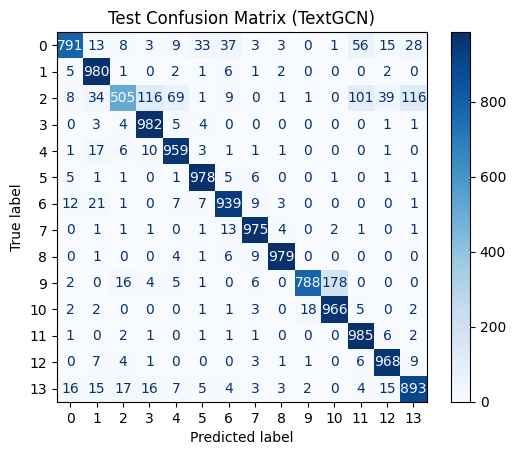

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load true test labels
df_test = pd.read_csv("sampled_data/sampled_test_cleaned.csv")
true_test = df_test["label"].values

# Load predictions
preds = np.load("sampled_data/predictions.npy")

# First 28000 = train, next 14000 = test
num_train = 28000
test_preds = preds[num_train:num_train + len(true_test)]

# Compute confusion matrix
cm = confusion_matrix(true_test, test_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(10,8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Test Confusion Matrix (TextGCN)")
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()


In [2]:
# Visualization + Interactive HTML (pyvis)
# Paste into a notebook cell and run (same folder as sampled_data/)
import os, json
import numpy as np
import scipy.sparse as sp
import networkx as nx
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
DATA_DIR = "sampled_data"
OUT_DIR = os.path.join(DATA_DIR, "presentation_assets"); os.makedirs(OUT_DIR, exist_ok=True)

EDGE_INDEX_PATH = os.path.join(DATA_DIR, "edge_index_full.npy")
EDGE_WEIGHT_PATH = os.path.join(DATA_DIR, "edge_weight_full.npy")
NODE_FEATS_PATH = os.path.join(DATA_DIR, "node_features_full.npy")
LABELS_MASKED_PATH = os.path.join(DATA_DIR, "labels_full.npy")        # train + -1 for test
TRUE_LABELS_PATH = os.path.join(DATA_DIR, "true_labels_full.npy")     # optional (train+test true labels)
PRED_PATH = os.path.join(DATA_DIR, "predictions.npy")                 # doc predictions

# Choose center doc:
# Option A: set absolute graph node id (graph doc id in [0..num_docs-1])
example_doc_node = 41501
# Option B: set offset into test-block (0 => first test doc)
example_doc_offset = 10

# visualization parameters
MAX_NEIGHBORS = 80
SPRING_K = 0.25
SEED = 42
EDGE_WEIGHT_THRESHOLD = 0.0   # prune edges weaker than this (0 => no prune)

# ---------------- optional pyvis ----------------
try:
    from pyvis.network import Network
    PYVIS_AVAILABLE = True
except Exception:
    PYVIS_AVAILABLE = False

# ---------------- validate files ----------------
for p in (EDGE_INDEX_PATH, EDGE_WEIGHT_PATH, NODE_FEATS_PATH, LABELS_MASKED_PATH, PRED_PATH):
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing required file: {p}")

# ---------------- load arrays ----------------
edge_index = np.load(EDGE_INDEX_PATH)
edge_weight = np.load(EDGE_WEIGHT_PATH)
node_feats = np.load(NODE_FEATS_PATH)
labels_masked = np.load(LABELS_MASKED_PATH)   # shape = (num_docs,) with -1 for test
preds = np.load(PRED_PATH)

num_docs = labels_masked.shape[0]
num_nodes = node_feats.shape[0]
num_words = num_nodes - num_docs
num_train = int(np.sum(labels_masked[:num_docs] != -1))

true_labels = None
if os.path.exists(TRUE_LABELS_PATH):
    arr = np.load(TRUE_LABELS_PATH)
    if arr.shape[0] == num_docs:
        true_labels = arr
    else:
        print("Warning: true_labels_full.npy length mismatch -> ignoring it (fall back to masked labels).")

# pick example doc graph id
if example_doc_node is None:
    example_doc_idx = num_train + example_doc_offset
else:
    example_doc_idx = int(example_doc_node)
if example_doc_idx < 0 or example_doc_idx >= num_docs:
    raise ValueError("example_doc_idx out of range")

print(f"num_train={num_train}  example_doc_idx={example_doc_idx}")

# ---------------- adjacency (symmetrize) ----------------
src = edge_index[0].astype(np.int64)
dst = edge_index[1].astype(np.int64)
w = edge_weight.astype(np.float32)
coo = sp.coo_matrix((w, (src, dst)), shape=(num_nodes, num_nodes), dtype=np.float32)
coo = coo + coo.transpose()
adj_csr = coo.tocsr()
# ensure self-loops (not strictly necessary for plotting)
if np.any(adj_csr.diagonal() == 0):
    adj_csr = adj_csr + sp.eye(num_nodes, dtype=np.float32, format='csr')

# ---------------- build k=1 subgraph around center ----------------
def get_k1_subgraph(adj_csr, center, max_neighbors=MAX_NEIGHBORS, threshold=EDGE_WEIGHT_THRESHOLD):
    row = adj_csr.getrow(center).tocoo()
    neigh = row.col.tolist()
    weights = row.data.tolist()
    pairs = [(int(n), float(w)) for n,w in zip(neigh, weights) if int(n) != center and float(w) > threshold]
    pairs = sorted(pairs, key=lambda x: x[1], reverse=True)[:max_neighbors]
    nodes = sorted({center} | {p[0] for p in pairs})
    sub = adj_csr[nodes, :][:, nodes].tocoo()
    rows, cols, dat = sub.row, sub.col, sub.data
    edges = []
    for i in range(len(dat)):
        u = nodes[int(rows[i])]
        v = nodes[int(cols[i])]
        weight = float(dat[i])
        if u == v: continue
        a,b = (u,v) if u<=v else (v,u)
        edges.append((a,b,weight))
    # deduplicate and keep max weight if multiple
    uniq = {}
    for u,v,wt in edges:
        if (u,v) not in uniq or uniq[(u,v)] < wt:
            uniq[(u,v)] = wt
    edges_uniq = [(u,v,uniq[(u,v)]) for (u,v) in sorted(uniq.keys())]
    return nodes, edges_uniq, {n:i for i,n in enumerate(nodes)}

sub_nodes, sub_edges, _ = get_k1_subgraph(adj_csr, example_doc_idx)
print("Subgraph nodes:", len(sub_nodes), "edges:", len(sub_edges))

# ---------------- create networkx graph ----------------
G = nx.Graph()
G.add_nodes_from(sub_nodes)
for u,v,wt in sub_edges:
    if u!=v:
        G.add_edge(u,v, weight=float(wt))

# ---------------- node visuals ----------------
node_colors = []
node_sizes = []
word_labels = {}
for n in G.nodes():
    if n == example_doc_idx:
        node_colors.append("grey")   # center test doc
        node_sizes.append(260)
    elif n < num_docs:
        # document node: colored red if training, light grey if test (not center)
        if labels_masked[n] != -1:
            node_colors.append("#ff6666")  # train doc
            node_sizes.append(140)
        else:
            node_colors.append("#bdbdbd")  # other test docs
            node_sizes.append(120)
    else:
        node_colors.append("#4da6ff")      # word node
        node_sizes.append(70)
        word_labels[n] = f"W{n-num_docs}"

# ---------------- edge visuals: grey only if connected to center, else blue; thickness ~ weight -----------
edge_list = list(G.edges())
edge_weights = [float(G[u][v].get("weight",1.0)) for u,v in edge_list]
if len(edge_weights):
    # scale widths: use sqrt to compress range, then map to [0.6,4.2]
    ws = np.sqrt(np.array(edge_weights))
    wmin, wmax = float(ws.min()), float(ws.max())
    span = wmax - wmin if wmax - wmin > 1e-12 else 1.0
    widths = (0.6 + 3.6 * (ws - wmin) / span).tolist()
else:
    widths = [1.0]*len(edge_list)

edge_colors = []
for (u,v) in edge_list:
    if example_doc_idx in (u,v):
        edge_colors.append("grey")       # only edges touching center doc are grey
    else:
        edge_colors.append("#1f77b4")    # other edges blue

# ---------------- static PNG plot ----------------
plt.figure(figsize=(10,10))
pos = nx.spring_layout(G, seed=SEED, k=SPRING_K)

nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color=edge_colors, width=widths, alpha=0.9)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
# draw only word labels (keeps view clean)
if word_labels:
    nx.draw_networkx_labels(G, pos, labels=word_labels, font_size=8)

# text info box with true & pred
center_true = (int(true_labels[example_doc_idx]) if true_labels is not None else (int(labels_masked[example_doc_idx]) if labels_masked[example_doc_idx] != -1 else None))
center_pred = int(preds[example_doc_idx]) if example_doc_idx < len(preds) else None
info_lines = [
    f"Document: D{example_doc_idx}",
    f"True label  : {center_true if center_true is not None else '(unavailable)'}",
    f"Pred label  : {center_pred if center_pred is not None else 'N/A'}"
]
plt.gcf().text(0.74, 0.58, "\n".join(info_lines), fontsize=11, bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="black", alpha=0.95))

plt.title(f"k=1 subgraph around doc {example_doc_idx} (edges touching center = grey)")
plt.axis("off")
png_out = os.path.join(OUT_DIR, f"subgraph_{example_doc_idx}.png")
plt.tight_layout(); plt.savefig(png_out, dpi=200); plt.close()
print("Saved static PNG ->", png_out)

# ---------------- optional interactive pyvis ----------------
out_html = None
if PYVIS_AVAILABLE:
    try:
        nt = Network(height="720px", width="100%", notebook=False, cdn_resources='in_line')
        nt.force_atlas_2based()
        nodes = list(G.nodes())
        # add nodes with tooltip text (True/Pred)
        for idx, n in enumerate(nodes):
            if n < num_docs:
                t = (int(true_labels[n]) if true_labels is not None else (int(labels_masked[n]) if labels_masked[n] != -1 else None))
                p = int(preds[n]) if n < len(preds) else None
                title = f"Node D{n}<br>True: {t if t is not None else '(unavail)'}<br>Pred: {p if p is not None else 'N/A'}"
                label = f"D{n}" if n < num_docs else f"W{n-num_docs}"
            else:
                title = f"Word W{n-num_docs}"
                label = f"W{n-num_docs}"
            color = node_colors[idx]
            size = max(8, min(60, int(node_sizes[idx] / 4)))
            nt.add_node(str(n), label=label, title=title, color=color, size=size)

        # add edges (color grey if touches center else blue)
        for (u,v), col, width in zip(edge_list, edge_colors, widths):
            nt.add_edge(str(u), str(v), color=col, width=max(1.0, float(width)))

        tmp_html = os.path.join(DATA_DIR, f"subgraph_{example_doc_idx}.tmp.html")
        out_html = os.path.join(DATA_DIR, f"subgraph_{example_doc_idx}.html")
        nt.write_html(tmp_html)

        # inject legend/center info HTML
        legend_html = f"""
        <div style="position:fixed; right:10px; top:10px; background:white; border:1px solid #ddd; padding:10px; z-index:9999;">
          <b>Legend</b><br/>
          <div style="margin-top:6px;"><span style='display:inline-block;width:12px;height:12px;background:#ff6666;margin-right:6px;'></span>Train doc</div>
          <div style="margin-top:6px;"><span style='display:inline-block;width:12px;height:12px;background:#bdbdbd;margin-right:6px;'></span>Other test doc</div>
          <div style="margin-top:6px;"><span style='display:inline-block;width:12px;height:12px;background:#4da6ff;margin-right:6px;'></span>Word node</div>
          <hr style="margin:8px 0"/>
          <div><b>Center D{example_doc_idx}</b></div>
          <div>True: {center_true if center_true is not None else '(unavailable)'}</div>
          <div>Pred: {center_pred if center_pred is not None else 'N/A'}</div>
        </div>
        """
        with open(tmp_html, "r", encoding="utf-8") as fh:
            html_text = fh.read()
        html_text = html_text.replace("</body>", legend_html + "\n</body>")
        with open(out_html, "w", encoding="utf-8") as fh:
            fh.write(html_text)
        os.remove(tmp_html)
        print("Saved interactive HTML ->", out_html)
    except Exception as e:
        print("pyvis export failed:", e)
else:
    print("pyvis not installed. Install with: pip install pyvis to get interactive HTML")

# ---------------- summary ----------------
summary = {"png": png_out, "html": out_html}
with open(os.path.join(OUT_DIR, "assets_summary.json"), "w") as fh:
    json.dump(summary, fh, indent=2)

print("Done. Summary:", summary)
print("Open the HTML in a browser (double-click) to interactively inspect nodes and hover tooltips.")


num_train=28000  example_doc_idx=41501
Subgraph nodes: 32 edges: 253
Saved static PNG -> sampled_data\presentation_assets\subgraph_41501.png
Saved interactive HTML -> sampled_data\subgraph_41501.html
Done. Summary: {'png': 'sampled_data\\presentation_assets\\subgraph_41501.png', 'html': 'sampled_data\\subgraph_41501.html'}
Open the HTML in a browser (double-click) to interactively inspect nodes and hover tooltips.
